In [148]:
import numpy as np
%matplotlib widget
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.activations import relu,linear
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)

from public_tests_a1 import * 

tf.keras.backend.set_floatx('float64')
from assigment_utils import *

tf.autograph.set_verbosity(0)
from assigment_utils import *

In [149]:
X,y,x_ideal,y_ideal = gen_data(18, 2, 0.7) #X and Y is data with the noise AND x ideal y ideal is data without noise
print("X.shape", X.shape, "y.shape", y.shape)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.33, random_state=1)
#training data is 0.67 AND Xtrain Ytrain is allocated to 0.67 of data 
print("X_train.shape", X_train.shape, "y_train.shape", y_train.shape)
print("X_test.shape", X_test.shape, "y_test.shape", y_test.shape) 


X.shape (18,) y.shape (18,)
X_train.shape (12,) y_train.shape (12,)
X_test.shape (6,) y_test.shape (6,)


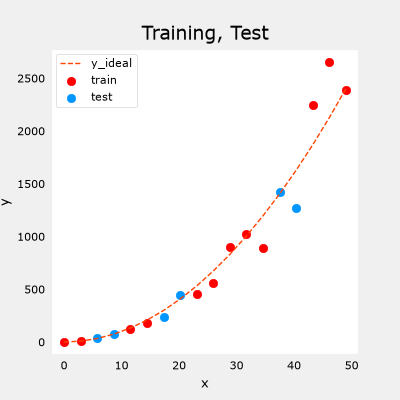

In [150]:
fig, ax = plt.subplots(1,1,figsize=(4,4))
ax.plot(x_ideal, y_ideal, "--", color = "orangered", label="y_ideal", lw=1)
ax.set_title("Training, Test",fontsize = 14)
ax.set_xlabel("x")
ax.set_ylabel("y")

ax.scatter(X_train, y_train, color = "red",           label="train")
ax.scatter(X_test, y_test,   color = dlc["dlblue"],   label="test")
ax.legend(loc='upper left')
plt.show()

In [151]:
def eval_mse(y, yhat):
    m = len(y)
    error = 0.0
    for i in range(m):
        error += ((yhat[i] - y[i])**2)
    error /= (2*m)
    return error

In [152]:
y_hat = np.array([2.4, 4.2])
y_tmp = np.array([2.3, 4.1])
eval_mse(y_hat, y_tmp)

# BEGIN UNIT TEST
test_eval_mse(eval_mse)   
# END UNIT TEST

 All tests passed.


In [153]:
#from sklearn.preprocessing import PolynomialFeatures
#from sklearn.linear_model import LinearRegression
#from sklearn.pipeline import make_pipeline
#from sklearn.metrics import mean_squared_error

#X_train_2d = X_train.reshape(-1, 1)
#X_test_2d = X_test.reshape(-1, 1)
# 1. Create the model pipeline (replaces lin_model(degree))
#degree = 10
#lmodel = make_pipeline(PolynomialFeatures(degree, include_bias=False), StandardScaler(), LinearRegression())

# 2. Train on training data (fits the polynomial curve)
#lmodel.fit(X_train_2d, y_train)

# 3. Predict on training data, find training error
#yhat = lmodel.predict(X_train_2d)
# Note: sklearn's mean_squared_error divides by m, whereas Andrew Ng's custom .mse often divides by 2m. 
# If your custom class method divided by 2m, you can write: mean_squared_error(y_train, yhat) / 2
#err_train = mean_squared_error(y_train, yhat) / 2  

# 4. Predict on test data, find test error
#yhat = lmodel.predict(X_test_2d)
#err_test = mean_squared_error(y_test, yhat) / 2

# THIS IS OFFICIAL SK LEARN WAY OF IMPLEMENTING IT

In [154]:
# create a model in sklearn, train on training data
degree = 10
lmodel = lin_model(degree)
lmodel.fit(X_train, y_train)

# predict on training data, find training error
yhat = lmodel.predict(X_train)
err_train = lmodel.mse(y_train, yhat)

# predict on test data, find error
yhat = lmodel.predict(X_test)
err_test = lmodel.mse(y_test, yhat)

In [155]:
print(f"training err {err_train:0.2f}, test err {err_test:0.2f}") 


training err 2086.18, test err 21384.05


In [156]:
# Generate  data
X,y, x_ideal,y_ideal = gen_data(40, 5, 0.7)
print("X.shape", X.shape, "y.shape", y.shape)

#split the data using sklearn routine 
X_train, X_, y_train, y_ = train_test_split(X,y,test_size=0.40, random_state=1)
X_cv, X_test, y_cv, y_test = train_test_split(X_,y_,test_size=0.50, random_state=1)
print("X_train.shape", X_train.shape, "y_train.shape", y_train.shape)
print("X_cv.shape", X_cv.shape, "y_cv.shape", y_cv.shape)
print("X_test.shape", X_test.shape, "y_test.shape", y_test.shape)

X.shape (40,) y.shape (40,)
X_train.shape (24,) y_train.shape (24,)
X_cv.shape (8,) y_cv.shape (8,)
X_test.shape (8,) y_test.shape (8,)


In [157]:
max_degree = 9
err_train = np.zeros(max_degree)    
err_cv = np.zeros(max_degree)      
x = np.linspace(0,int(X.max()),100)  
y_pred = np.zeros((100,max_degree))  #columns are lines to plot

for degree in range(max_degree):
    lmodel = lin_model(degree+1)
    lmodel.fit(X_train, y_train)
    yhat = lmodel.predict(X_train)
    err_train[degree] = lmodel.mse(y_train, yhat)
    yhat = lmodel.predict(X_cv)
    err_cv[degree] = lmodel.mse(y_cv, yhat)
    y_pred[:,degree] = lmodel.predict(x)
     #optimal degree
optimal_degree = np.argmin(err_cv)+1

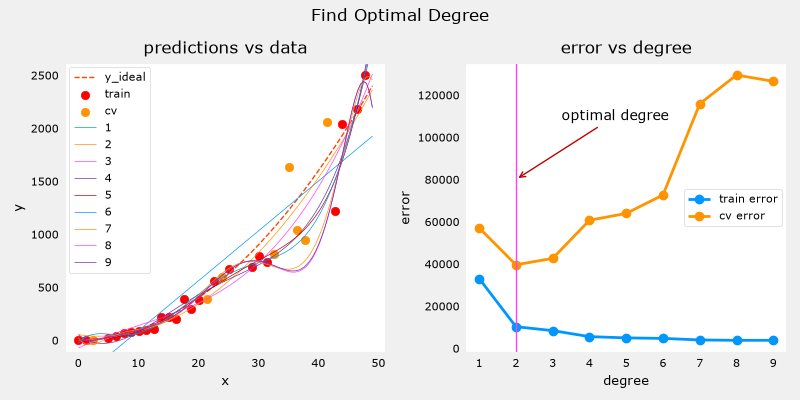

In [158]:
plt.close("all")
plt_optimal_degree(X_train, y_train, X_cv, y_cv, x, y_pred, x_ideal, y_ideal, 
                   err_train, err_cv, optimal_degree, max_degree)

In [159]:
	
lambda_range = np.array([0.0, 1e-6, 1e-5, 1e-4,1e-3,1e-2, 1e-1,1,10,100])
num_steps = len(lambda_range)
degree = 10
err_train = np.zeros(num_steps)    
err_cv = np.zeros(num_steps)       
x = np.linspace(0,int(X.max()),100) 
y_pred = np.zeros((100,num_steps))  #columns are lines to plot

for i in range(num_steps):
    lambda_= lambda_range[i]
    lmodel = lin_model(degree, regularization=True, lambda_=lambda_)
    lmodel.fit(X_train, y_train)
    yhat = lmodel.predict(X_train)
    err_train[i] = lmodel.mse(y_train, yhat)
    yhat = lmodel.predict(X_cv)
    err_cv[i] = lmodel.mse(y_cv, yhat)
    y_pred[:,i] = lmodel.predict(x)
    
optimal_reg_idx = np.argmin(err_cv)  #find optimal regularization

In [160]:
#execrise 2
def eval_cat_err(y, yhat):
    m = len(y)
    incorrect = 0.0
    for i in range(m):
        if (y[i] != yhat[i]):
            incorrect += 1
    incorrect /= m
    return incorrect

In [161]:
y_hat = np.array([1, 2, 0])
y_tmp = np.array([1, 2, 3])
print(f"categorization error {np.squeeze(eval_cat_err(y_hat, y_tmp)):0.3f}, expected:0.333" )
y_hat = np.array([[1], [2], [0], [3]])
y_tmp = np.array([[1], [2], [1], [3]])
print(f"categorization error {np.squeeze(eval_cat_err(y_hat, y_tmp)):0.3f}, expected:0.250" )

# BEGIN UNIT TEST  
test_eval_cat_err(eval_cat_err)
# END UNIT TEST
# BEGIN UNIT TEST  
test_eval_cat_err(eval_cat_err)
# END UNIT TEST

categorization error 0.333, expected:0.333
categorization error 0.250, expected:0.250
 All tests passed.
 All tests passed.


In [ ]:
# UNQ_C3
# GRADED CELL: model

#COMPLEX MODEL
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)


tf.random.set_seed(1234)
model = Sequential(
    [
        ### START CODE HERE ### 
        tf.keras.layers.Dense(120, activation="relu"),
        tf.keras.layers.Dense(40, activation="relu"),
        tf.keras.layers.Dense(6, activation="linear")
        ### END CODE HERE ### 
    ], name="Complex"
)
model.compile(
    ### START CODE HERE ### 
    loss=SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    ### END CODE HERE ### 
)

In [ ]:
X_train = np.expand_dims(X_train, axis=-1)
model.fit(
    X_train, y_train,
    epochs=1000
)

training_cerr_complex = eval_cat_err(y_train, model_predict(X_train))
cv_cerr_complex = eval_cat_err(y_cv, model_predict(X_cv))
print(f"categorization error, training, complex model: {training_cerr_complex:0.3f}")
print(f"categorization error, cv,       complex model: {cv_cerr_complex:0.3f}")

Epoch 1/1000


W0000 00:00:1784881426.798100 24674198 op_kernel.cc:1858] OP_REQUIRES failed at sparse_xent_op.cc:103 : INVALID_ARGUMENT: Received a label value of 2502 which is outside the valid range of [0, 6).  Label values: 0 799 2038 222 391 86 299 78 25 42 691 557 217 2502 111 202 2184 675 379 740 67 1 1215 99


InvalidArgumentError: Graph execution error:

Detected at node compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/SparseSoftmaxCrossEntropyWithLogits defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/opt/anaconda3/envs/clear_env/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/opt/anaconda3/envs/clear_env/lib/python3.12/site-packages/traitlets/config/application.py", line 1082, in launch_instance

  File "/opt/anaconda3/envs/clear_env/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 807, in start

  File "/opt/anaconda3/envs/clear_env/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/opt/anaconda3/envs/clear_env/lib/python3.12/asyncio/base_events.py", line 645, in run_forever

  File "/opt/anaconda3/envs/clear_env/lib/python3.12/asyncio/base_events.py", line 1999, in _run_on

In [164]:
#SIMPLE MODEL
tf.random.set_seed(1234)
model_s = Sequential(
    [
        ### START CODE HERE ### 
        tf.keras.layers.Dense(6, activation="relu"),
        tf.keras.layers.Dense(6, activation="linear")
        ### END CODE HERE ### 
    ], name = "Simple"
)
model_s.compile(
    ### START CODE HERE ### 
    loss=SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    ### START CODE HERE ### 
)

In [ ]:
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)

# BEGIN UNIT TEST
model_s.fit(
    X_train,y_train,
    epochs=1000
)

training_cerr_simple = eval_cat_err(y_train, model_predict_s(X_train))
cv_cerr_simple = eval_cat_err(y_cv, model_predict_s(X_cv))
print(f"categorization error, training, simple model, {training_cerr_simple:0.3f}, complex model: {training_cerr_complex:0.3f}" )
print(f"categorization error, cv,       simple model, {cv_cerr_simple:0.3f}, complex model: {cv_cerr_complex:0.3f}" )

Epoch 1/1000


W0000 00:00:1784881657.978936 24674197 op_kernel.cc:1858] OP_REQUIRES failed at sparse_xent_op.cc:103 : INVALID_ARGUMENT: Received a label value of 2502 which is outside the valid range of [0, 6).  Label values: 0 799 2038 222 391 86 299 78 25 42 691 557 217 2502 111 202 2184 675 379 740 67 1 1215 99


InvalidArgumentError: Graph execution error:

Detected at node compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/SparseSoftmaxCrossEntropyWithLogits defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/opt/anaconda3/envs/clear_env/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/opt/anaconda3/envs/clear_env/lib/python3.12/site-packages/traitlets/config/application.py", line 1082, in launch_instance

  File "/opt/anaconda3/envs/clear_env/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 807, in start

  File "/opt/anaconda3/envs/clear_env/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/opt/anaconda3/envs/clear_env/lib/python3.12/asyncio/base_events.py", line 645, in run_forever

  File "/opt/anaconda3/envs/clear_env/lib/python3.12/asyncio/base_events.py", line 1999, in _run_on

In [ ]:
#COMPLEX MODEL WITH REGULARIZATION!
tf.random.set_seed(1234)
model_r = Sequential(
    [
        ### START CODE HERE ### 
        tf.keras.layers.Dense(120, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.1)),
        tf.keras.layers.Dense(40, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.1)),
        tf.keras.layers.Dense(6, activation="linear")
        ### START CODE HERE ### 
    ], name= None
)
model_r.compile(
    ### START CODE HERE ### 
    loss=SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    ### START CODE HERE ### 
)

In [ ]:
model_r.fit(
    X_train, y_train,
    epochs=1000
)
training_cerr_reg = eval_cat_err(y_train, model_predict_r(X_train))
cv_cerr_reg = eval_cat_err(y_cv, model_predict_r(X_cv))
test_cerr_reg = eval_cat_err(y_test, model_predict_r(X_test))
print(f"categorization error, training, regularized: {training_cerr_reg:0.3f}, simple model, {training_cerr_simple:0.3f}, complex model: {training_cerr_complex:0.3f}" )
print(f"categorization error, cv,       regularized: {cv_cerr_reg:0.3f}, simple model, {cv_cerr_simple:0.3f}, complex model: {cv_cerr_complex:0.3f}" )

In [ ]:
#TRY MANY REGUALRIZATION VALUES 
tf.random.set_seed(1234)
lambdas = [0.0, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3]
models=[None] * len(lambdas)
for i in range(len(lambdas)):
    lambda_ = lambdas[i]
    models[i] =  Sequential(
        [
            Dense(120, activation = 'relu', kernel_regularizer=tf.keras.regularizers.l2(lambda_)),
            Dense(40, activation = 'relu', kernel_regularizer=tf.keras.regularizers.l2(lambda_)),
            Dense(classes, activation = 'linear')
        ]
    )
    models[i].compile(
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        optimizer=tf.keras.optimizers.Adam(0.01),
    )

    models[i].fit(
        X_train,y_train,
        epochs=1000
    )
    print(f"Finished lambda = {lambda_}")